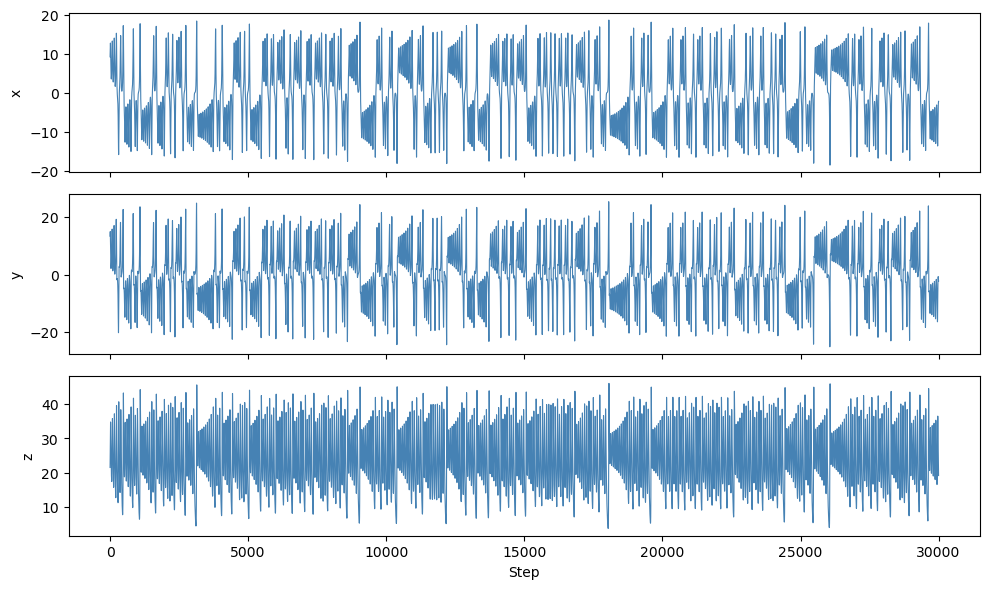

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time

import reservoirpy
from reservoirpy.mat_gen import uniform
from reservoirpy.nodes import Reservoir, Ridge, ScikitLearnNode
from sklearn.linear_model import Lasso

reservoirpy.set_seed(42)

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..',)))
from lib.utils.reservoirpy import *

# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../data/chaotic_data/lorenz_system.csv', delimiter=',')

# Expecting shape (T, 3) with columns = (x, y, z).
# If your CSV has an extra time column, do: dataset = dataset[:, 1:4]
assert dataset.ndim == 2 and dataset.shape[1] >= 3, \
    f"Expected (T, >=3) Lorenz array, got {dataset.shape}"
dataset = dataset[:, :3]

dim_names = ['x', 'y', 'z']

# Visualize the three components
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for d in range(3):
    axes[d].plot(dataset[:, d], color='steelblue', linewidth=0.8)
    axes[d].set_ylabel(dim_names[d])
axes[-1].set_xlabel('Step')
plt.tight_layout()
plt.show()

Total combinations to evaluate: 1080
[20/1080]  elapsed: 8s  current best NRMSE: 0.000163
[40/1080]  elapsed: 15s  current best NRMSE: 0.000163
[60/1080]  elapsed: 23s  current best NRMSE: 0.000163
[80/1080]  elapsed: 30s  current best NRMSE: 0.000163
[100/1080]  elapsed: 38s  current best NRMSE: 0.000163
[120/1080]  elapsed: 45s  current best NRMSE: 0.000163
[140/1080]  elapsed: 55s  current best NRMSE: 0.000163
[160/1080]  elapsed: 71s  current best NRMSE: 0.000163
[180/1080]  elapsed: 87s  current best NRMSE: 0.000163
[200/1080]  elapsed: 103s  current best NRMSE: 0.000163
[220/1080]  elapsed: 120s  current best NRMSE: 0.000163
[240/1080]  elapsed: 136s  current best NRMSE: 0.000163
[260/1080]  elapsed: 152s  current best NRMSE: 0.000163
[280/1080]  elapsed: 175s  current best NRMSE: 0.000163
[300/1080]  elapsed: 204s  current best NRMSE: 0.000163
[320/1080]  elapsed: 233s  current best NRMSE: 0.000163
[340/1080]  elapsed: 262s  current best NRMSE: 0.000163
[360/1080]  elapsed: 292s

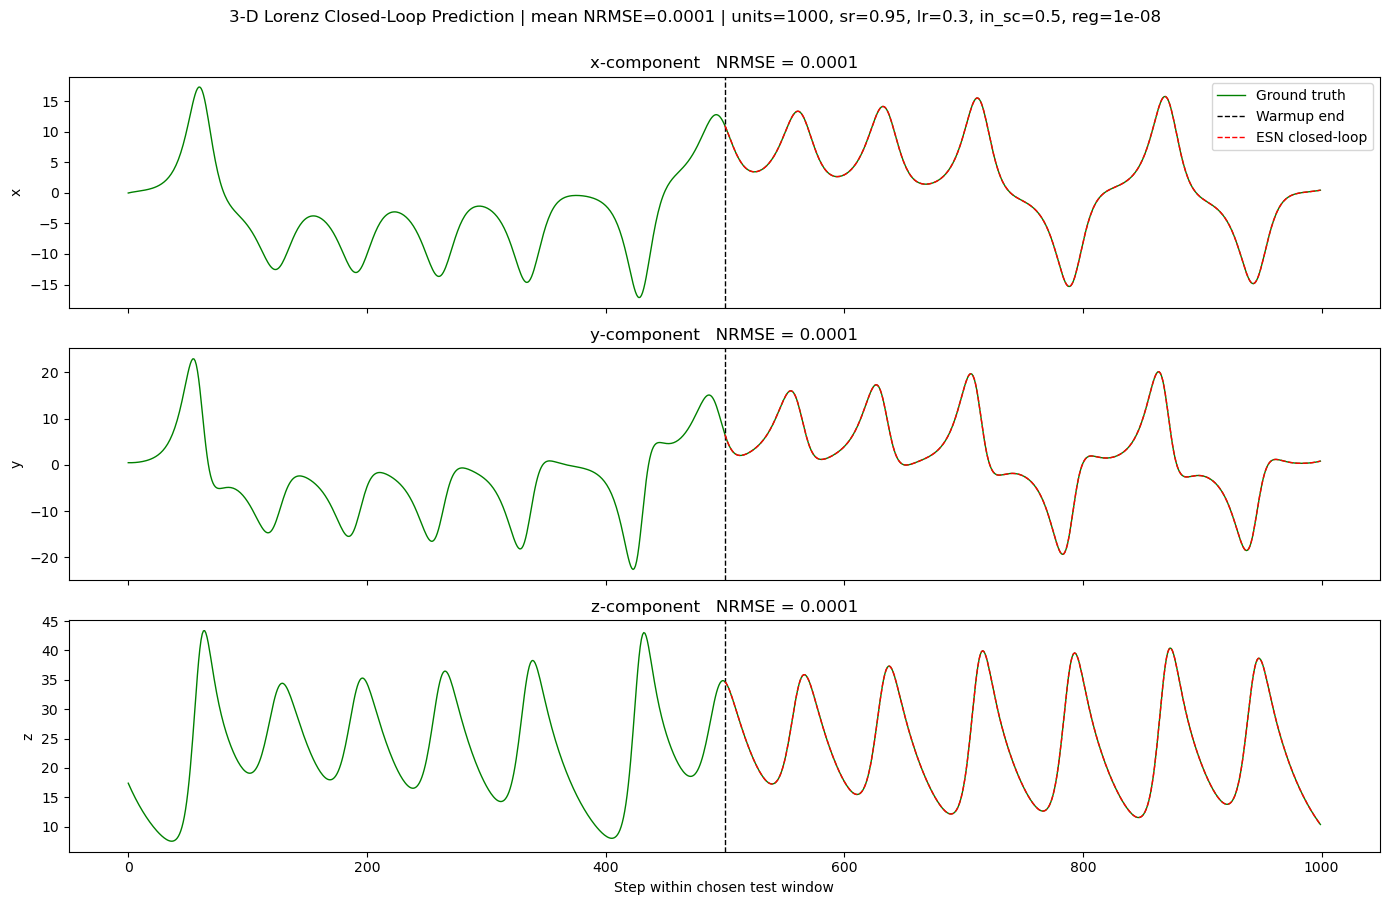

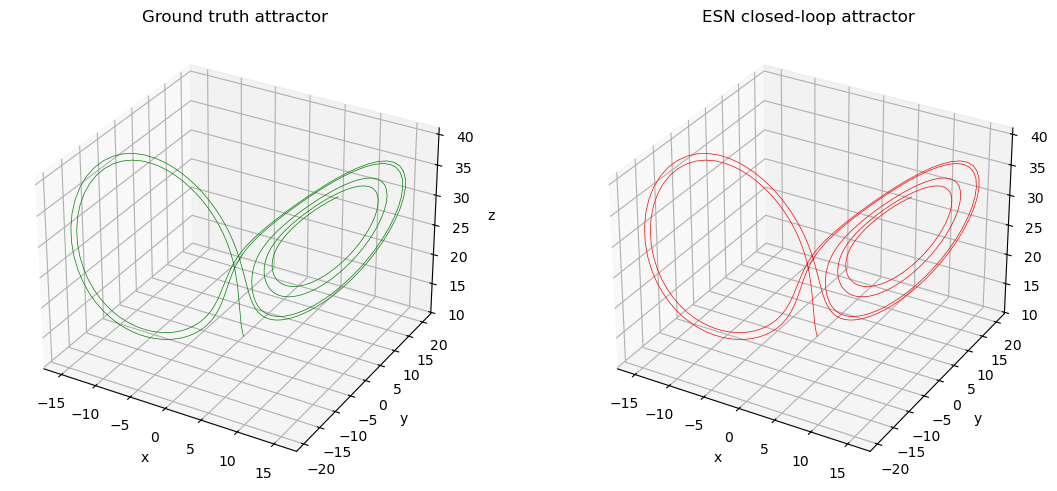

In [3]:
# ==========================================================
# DATA PREPARATION
# ==========================================================
# 3-D Lorenz: data shape is already (T, 3)
data = dataset

# One-step supervised pairs (input -> next-step state)
X_raw = data[:-1]   # shape (T-1, 3)
Y_raw = data[1:]    # shape (T-1, 3)


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len = 10000
test_start = 10000
test_len = 20000

regression_model = "ridge"
seed = 42

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]

X_test_raw = X_raw[test_start:test_start + test_len]
Y_test_raw = Y_raw[test_start:test_start + test_len]

# Output dimensionality (Lorenz = 3)
n_dim = X_train_raw.shape[1]


# ==========================================================
# PARAMETER GRID
# ==========================================================
param_grid = {
    "normalization":          ["zscore"],
    "train_warmup":           [200],
    "test_warmup":            [500],
    "units":                  [500, 1000],
    "reservoir_connectivity": [0.2, 0.5, 0.8, 1.0],
    "sr":                     [0.8, 0.9, 0.95, 1.0, 1.2],
    "lr":                     [0.1, 0.3, 0.5],
    "input_scaling":          [0.5, 0.8, 1.0],
    "regression":             [1e-8, 1e-6, 1e-5],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))

print(f"Total combinations to evaluate: {len(combos)}")


# ==========================================================
# EVALUATION FUNCTION (3-D)
# ==========================================================
def evaluate_esn(
    normalization,
    train_warmup,
    test_warmup,
    units,
    reservoir_connectivity,
    sr,
    lr,
    input_scaling,
    regression,
    seed=42
):
    """
    Build, train, synchronize, and run closed-loop prediction on 3-D Lorenz.
    Returns NRMSE in scaled space, averaged over the 3 components.
    """
    try:
        if test_warmup >= test_len:
            return np.inf

        # -------------------------
        # Fit scaler on training inputs only (per-dimension)
        # -------------------------
        scaler = fit_scaler(X_train_raw, method=normalization)

        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test  = transform_array(X_test_raw,  scaler)
        Y_test  = transform_array(Y_test_raw,  scaler)

        pred_len = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, :]   # (pred_len, 3)

        if train_warmup >= len(X_train):
            return np.inf

        # -------------------------
        # Reservoir
        # -------------------------
        reservoir = Reservoir(
            units=int(units),
            lr=lr,
            W=uniform(low=-0.5, high=0.5,
                      connectivity=reservoir_connectivity, sr=sr),
            Win=uniform(low=-0.5 * input_scaling, high=0.5 * input_scaling,
                        connectivity=1.0),
            bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
            activation="tanh",
            seed=seed
        )

        if regression_model == "ridge":
            readout = Ridge(ridge=regression)
        else:
            readout = ScikitLearnNode(model=Lasso, alpha=regression,
                                      max_iter=50000, tol=1e-3)

        esn = reservoir >> readout

        # -------------------------
        # Train: reservoirpy automatically handles 3-D input/output
        # -------------------------
        esn.fit(X_train, Y_train, warmup=train_warmup)

        # -------------------------
        # Test: reset + synchronize + closed loop
        # -------------------------
        esn.reset()

        if test_warmup > 0:
            esn.run(X_test[:test_warmup])

        # Start closed loop from the first test point after warmup
        current_input = X_test[test_warmup:test_warmup + 1]   # shape (1, 3)
        Y_pred_scaled = np.zeros((pred_len, n_dim))

        for t in range(pred_len):
            pred = esn.run(current_input)
            pred = np.asarray(pred).reshape(1, n_dim)
            Y_pred_scaled[t, :] = pred[0, :]
            current_input = pred   # feed prediction back as next input

        # Divergence check
        if np.any(np.isnan(Y_pred_scaled)) or np.any(np.isinf(Y_pred_scaled)):
            return np.inf
        if np.max(np.abs(Y_pred_scaled)) > 1e6:
            return np.inf

        # NRMSE per-dimension, then average
        rmse_per_dim = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2, axis=0))
        std_per_dim  = np.std(Y_true_scaled, axis=0)
        if np.any(std_per_dim == 0):
            return np.inf

        nrmse_per_dim = rmse_per_dim / std_per_dim
        return float(np.mean(nrmse_per_dim))

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_esn(**params, seed=seed)
    results.append({**params, "nrmse": nrmse})

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(f"[{i+1}/{len(combos)}]  elapsed: {elapsed:.0f}s  "
              f"current best NRMSE: {best_nrmse:.6f}")

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("GRID SEARCH COMPLETE (3-D Lorenz)")
print(f"Train interval      : [0 : {train_len}]")
print(f"Test interval       : [{test_start} : {test_start + test_len}]")
print(f"Total time          : {total_time:.1f}s "
      f"({total_time/len(combos):.2f}s per trial)")
print(f"Regression model    : {regression_model}")
print(f"Best mean NRMSE     : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 10 configurations:")
print(f"{'Rank':>4}  {'norm':>8}  {'tr_wu':>5}  {'te_wu':>5}  "
      f"{'units':>5}  {'conn':>5}  {'sr':>4}  {'lr':>4}  "
      f"{'in_sc':>6}  {'reg':>8}  {'NRMSE':>10}")
print("-" * 100)
for rank, r in enumerate(results_sorted[:10], 1):
    print(f"{rank:4d}  {r['normalization']:>8s}  "
          f"{r['train_warmup']:5d}  {r['test_warmup']:5d}  "
          f"{int(r['units']):5d}  {r['reservoir_connectivity']:5.2f}  "
          f"{r['sr']:4.2f}  {r['lr']:4.1f}  {r['input_scaling']:6.2f}  "
          f"{r['regression']:8.1e}  {r['nrmse']:10.6f}")


# ==========================================================
# REBUILD BEST MODEL
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])

X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best  = transform_array(X_test_raw,  best_scaler)
Y_test_best  = transform_array(Y_test_raw,  best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_reservoir = Reservoir(
    units=int(best_params["units"]),
    lr=best_params["lr"],
    W=uniform(low=-0.5, high=0.5,
              connectivity=best_params["reservoir_connectivity"],
              sr=best_params["sr"]),
    Win=uniform(low=-0.5 * best_params["input_scaling"],
                high=0.5 * best_params["input_scaling"],
                connectivity=1.0),
    bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
    activation="tanh",
    seed=seed
)

if regression_model == "ridge":
    best_readout = Ridge(ridge=best_params["regression"])
else:
    best_readout = ScikitLearnNode(model=Lasso,
                                   alpha=best_params["regression"],
                                   max_iter=10000)

best_esn = best_reservoir >> best_readout

best_esn.fit(X_train_best, Y_train_best, warmup=best_params["train_warmup"])

best_esn.reset()
if best_params["test_warmup"] > 0:
    best_esn.run(X_test_best[:best_params["test_warmup"]])

Y_pred_best_scaled = np.zeros((best_pred_len, n_dim))
current_input = X_test_best[
    best_params["test_warmup"]:best_params["test_warmup"] + 1
]

for t in range(best_pred_len):
    pred = best_esn.run(current_input)
    pred = np.asarray(pred).reshape(1, n_dim)
    Y_pred_best_scaled[t, :] = pred[0, :]
    current_input = pred

Y_true_best_scaled = Y_test_best[
    best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len, :
]

# Inverse transform back to original scale (per dimension)
Y_pred_best = inverse_transform_array(Y_pred_best_scaled, best_scaler)
Y_true_best = inverse_transform_array(Y_true_best_scaled, best_scaler)

# Per-dimension and aggregate metrics in original scale
rmse_per_dim = np.sqrt(np.mean((Y_true_best - Y_pred_best) ** 2, axis=0))
std_per_dim  = np.std(Y_true_best, axis=0)
nrmse_per_dim = rmse_per_dim / std_per_dim

print("\nFinal best-model metrics in original scale:")
for d in range(n_dim):
    print(f"  {dim_names[d]}: RMSE={rmse_per_dim[d]:.6f}   "
          f"NRMSE={nrmse_per_dim[d]:.6f}")
print(f"  mean NRMSE = {np.mean(nrmse_per_dim):.6f}")


# ==========================================================
# VISUALIZATION: 3 PANELS, ONE PER COMPONENT
# ==========================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

t_full = np.arange(test_len)
t_pred = np.arange(best_params["test_warmup"],
                   best_params["test_warmup"] + best_pred_len)

for d in range(n_dim):
    ax = axes[d]
    ax.plot(t_full, Y_test_raw[:, d],
            c="green", linewidth=1.0, label="Ground truth")
    ax.axvline(best_params["test_warmup"], linestyle="--",
               c="k", linewidth=1.0, label="Warmup end")
    ax.plot(t_pred, Y_pred_best[:, d], linestyle="--",
            c="red", linewidth=1.0, label="ESN closed-loop")
    ax.set_ylabel(dim_names[d])
    ax.set_title(f"{dim_names[d]}-component   "
                 f"NRMSE = {nrmse_per_dim[d]:.4f}")
    if d == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel("Step within chosen test window")

fig.suptitle(
    f"3-D Lorenz Closed-Loop Prediction | mean NRMSE={np.mean(nrmse_per_dim):.4f} | "
    f"units={int(best_params['units'])}, "
    f"sr={best_params['sr']}, lr={best_params['lr']}, "
    f"in_sc={best_params['input_scaling']}, "
    f"reg={best_params['regression']:.0e}",
    y=1.00
)

plt.tight_layout()
plt.show()


# ==========================================================
# OPTIONAL: 3-D ATTRACTOR COMPARISON
# ==========================================================
# Useful sanity check: do the reconstructed dynamics live on the
# Lorenz butterfly, or has the RC drifted to a different attractor?
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(Y_true_best[:, 0], Y_true_best[:, 1], Y_true_best[:, 2],
         color='green', linewidth=0.5)
ax1.set_title('Ground truth attractor')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(Y_pred_best[:, 0], Y_pred_best[:, 1], Y_pred_best[:, 2],
         color='red', linewidth=0.5)
ax2.set_title('ESN closed-loop attractor')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================================
# PREREQUISITES
# ==========================================================
# This notebook assumes the previous training notebook has been
# run, leaving the following objects in memory:
#
#   best_esn         - trained ReservoirPy model (Reservoir >> Ridge)
#   best_reservoir   - the Reservoir node inside best_esn
#   best_readout     - the Ridge node (with trained Wout, bias)
#   best_scaler      - fitted scaler for inverse/forward transforms
#   X_test_best      - scaled test data, shape (test_len, 3)
#   best_params      - dict of best hyperparameters
#   n_dim            - 3
#
# We extract the trained weights and run the coupled simulation
# using direct matrix operations — this is faster than going through
# ReservoirPy's run() loop and gives us full control over coupling.

# ==========================================================
# EXTRACT TRAINED WEIGHTS FROM THE BEST ESN
# ==========================================================
W_res = best_reservoir.W.toarray() if hasattr(best_reservoir.W, 'toarray') \
        else np.asarray(best_reservoir.W)
W_in  = best_reservoir.Win.toarray() if hasattr(best_reservoir.Win, 'toarray') \
        else np.asarray(best_reservoir.Win)
b_res = np.asarray(best_reservoir.bias).ravel()

W_out = np.asarray(best_readout.Wout)   # shape (units, 3) in reservoirpy
b_out = np.asarray(best_readout.bias).ravel()

# ReservoirPy stores Wout with shape (units, output_dim).
# We'll use convention: y_pred = r @ W_out + b_out  (1, units) @ (units, 3) -> (1, 3)
# Verify shapes:
N = W_res.shape[0]
print(f"Reservoir size N = {N}")
print(f"W_res:  {W_res.shape}")
print(f"W_in:   {W_in.shape}")
print(f"b_res:  {b_res.shape}")
print(f"W_out:  {W_out.shape}")
print(f"b_out:  {b_out.shape}")

leak = best_params["lr"]

Reservoir size N = 1000
W_res:  (1000, 1000)
W_in:   (1000, 3)
b_res:  (1000,)
W_out:  (1000, 3)
b_out:  (3,)



Warm-up source data shape: (4000, 3)
Prepared 5 initial-state pairs
  pair 0: ||r1 - r2|| =   5.171   y1 = [+0.38 +0.41 -1.07]   y2 = [+0.26 +0.15 -0.66]
  pair 1: ||r1 - r2|| =  17.790   y1 = [-0.55 +0.32 +1.02]   y2 = [+1.71 +0.72 +1.52]
  pair 2: ||r1 - r2|| =   8.472   y1 = [-0.73 -1.04 -0.42]   y2 = [+0.35 +0.37 -1.47]
  pair 3: ||r1 - r2|| =   8.175   y1 = [-0.29 -0.56 -1.00]   y2 = [-0.18 +0.02 +0.04]
  pair 4: ||r1 - r2|| =  16.615   y1 = [+0.62 +0.16 +0.29]   y2 = [+0.39 +0.44 -2.16]

Sanity check at alpha = 0.0 (no coupling):
  ✓ finite. y1 range: [-2.46, 2.95]   y2 range: [-2.27, 3.11]

Sanity check at alpha = 0.5:
  ✓ finite. E (after 500-step transient) = 0.00000

Alpha sweep over 6 values: 0.00 ... 0.10
Per simulation: 15000 steps (5000 transient + 10000 averaging)
  [ 1/6] alpha = 0.000  E = 2.16638 ± 0.11740  (elapsed 22s)
  [ 2/6] alpha = 0.020  E = 2.41388 ± 1.20694  (elapsed 42s)
  [ 3/6] alpha = 0.040  E = 1.22633 ± 1.50194  (elapsed 62s)
  [ 4/6] alpha = 0.060  E 

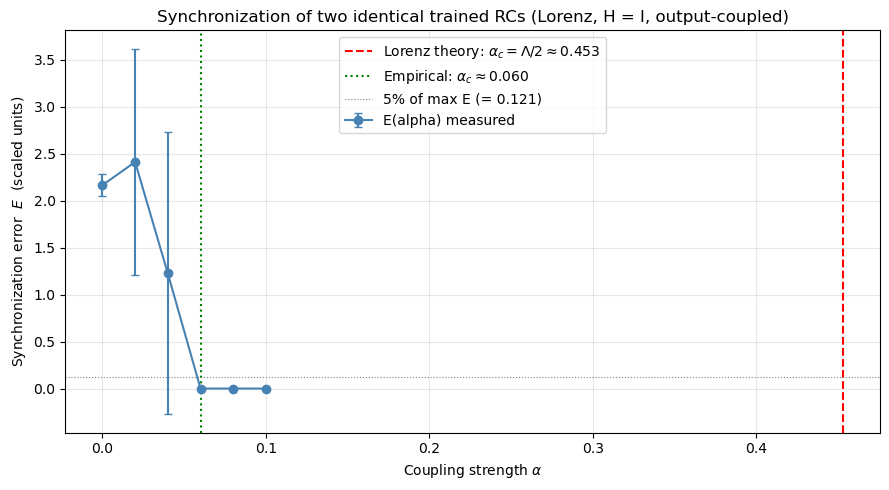

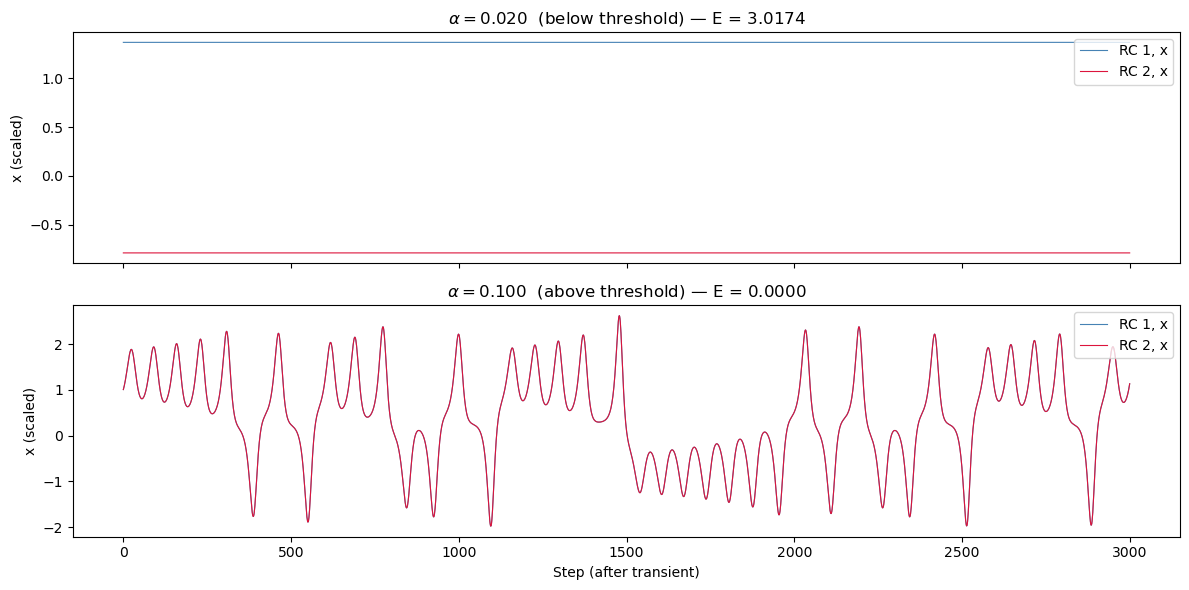

In [11]:
# ==========================================================
# CORE STEP FUNCTION (single reservoir, one step)
# ==========================================================
def reservoir_step(r, u, W_res, W_in, b_res, leak):
    """One leaky-tanh reservoir update.
    r: (N,)   current hidden state
    u: (3,)   input
    """
    pre = W_res @ r + W_in @ u + b_res
    return (1.0 - leak) * r + leak * np.tanh(pre)

def readout(r, W_out, b_out):
    """Map reservoir state to 3-D output."""
    return r @ W_out + b_out


# ==========================================================
# WARM UP TWO RESERVOIRS WITH DIFFERENT SEGMENTS
# ==========================================================
# Use the TRAINING data for warm-up segments — there's much more of
# it (train_len = 4000) than the test window (test_len = 1000), and
# the trained RC is consistent with this data by construction.

def warmup_reservoir(driving_signal, W_res, W_in, b_res, leak, N):
    """Drive a fresh reservoir with `driving_signal` and return final state."""
    r = np.zeros(N)
    for u in driving_signal:
        r = reservoir_step(r, u, W_res, W_in, b_res, leak)
    return r

warmup_len = 800

# Source data for warm-up segments. Use the scaled training inputs
# directly — same scaler as the RC was trained with.
warmup_source = X_train_best   # shape (train_len, 3)
print(f"\nWarm-up source data shape: {warmup_source.shape}")

# Choose well-separated, non-overlapping windows
realization_offsets = [
    (0,    1500),
    (200,  1700),
    (400,  1900),
    (600,  2100),
    (800,  2300),
]
n_realizations = len(realization_offsets)

# Validate that all segments fit
max_idx_needed = max(o2 + warmup_len for (_, o2) in realization_offsets)
assert max_idx_needed <= len(warmup_source), (
    f"Need at least {max_idx_needed} rows of warm-up data, "
    f"have {len(warmup_source)}. Reduce offsets or warmup_len."
)

initial_state_pairs = []
for (o1, o2) in realization_offsets:
    s1 = warmup_source[o1:o1 + warmup_len]
    s2 = warmup_source[o2:o2 + warmup_len]
    r1 = warmup_reservoir(s1, W_res, W_in, b_res, leak, N)
    r2 = warmup_reservoir(s2, W_res, W_in, b_res, leak, N)
    initial_state_pairs.append((r1, r2))

assert len(initial_state_pairs) > 0, "No initial state pairs created!"
print(f"Prepared {len(initial_state_pairs)} initial-state pairs")

# Diagnostic: how different are the warm-up states, and what does the
# RC predict at the end of each warm-up?
for k, (r1, r2) in enumerate(initial_state_pairs):
    diff = np.linalg.norm(r1 - r2)
    y1 = readout(r1, W_out, b_out)
    y2 = readout(r2, W_out, b_out)
    print(f"  pair {k}: ||r1 - r2|| = {diff:7.3f}   "
          f"y1 = [{y1[0]:+.2f} {y1[1]:+.2f} {y1[2]:+.2f}]   "
          f"y2 = [{y2[0]:+.2f} {y2[1]:+.2f} {y2[2]:+.2f}]")


# ==========================================================
# COUPLED CLOSED-LOOP SIMULATION (with relaxed divergence guard)
# ==========================================================
def simulate_coupled_pair(r1_0, r2_0, alpha, n_steps,
                          W_res, W_in, b_res, W_out, b_out, leak,
                          divergence_bound=1e4):
    """
    Run two identical ESNs in closed loop, output-coupled with H = I.
    Returns y1_traj, y2_traj  each of shape (n_steps, 3),
    or (None, None) if either trajectory diverges.
    """
    r1 = r1_0.copy()
    r2 = r2_0.copy()

    y1_traj = np.zeros((n_steps, 3))
    y2_traj = np.zeros((n_steps, 3))

    for t in range(n_steps):
        y1 = readout(r1, W_out, b_out)
        y2 = readout(r2, W_out, b_out)

        # Diffusive coupling on the 3-D output
        u1 = y1 + alpha * (y2 - y1)
        u2 = y2 + alpha * (y1 - y2)

        r1 = reservoir_step(r1, u1, W_res, W_in, b_res, leak)
        r2 = reservoir_step(r2, u2, W_res, W_in, b_res, leak)

        y1_traj[t] = y1
        y2_traj[t] = y2

        if (not np.all(np.isfinite(y1))) or (not np.all(np.isfinite(y2))):
            return None, None
        if max(np.max(np.abs(y1)), np.max(np.abs(y2))) > divergence_bound:
            return None, None

    return y1_traj, y2_traj


# ==========================================================
# QUICK SANITY CHECK BEFORE THE SWEEP
# ==========================================================
# Run a single short simulation at alpha = 0 (no coupling) and
# at alpha = 0.5 (above expected threshold), to confirm we get
# finite trajectories before launching the full sweep.

print("\nSanity check at alpha = 0.0 (no coupling):")
r1_0, r2_0 = initial_state_pairs[0]
y1_test, y2_test = simulate_coupled_pair(r1_0, r2_0, 0.0, 2000,
                                         W_res, W_in, b_res,
                                         W_out, b_out, leak)
if y1_test is None:
    print("  ✗ DIVERGED — trained RC is not stable in closed loop.")
    print("    Check the previous notebook's attractor plot.")
else:
    print(f"  ✓ finite. y1 range: "
          f"[{y1_test.min():.2f}, {y1_test.max():.2f}]   "
          f"y2 range: [{y2_test.min():.2f}, {y2_test.max():.2f}]")

print("\nSanity check at alpha = 0.5:")
y1_test, y2_test = simulate_coupled_pair(r1_0, r2_0, 0.5, 2000,
                                         W_res, W_in, b_res,
                                         W_out, b_out, leak)
if y1_test is None:
    print("  ✗ DIVERGED at alpha = 0.5.")
else:
    e_test = sync_error(y1_test, y2_test, 500)
    print(f"  ✓ finite. E (after 500-step transient) = {e_test:.5f}")


# ==========================================================
# ALPHA SWEEP
# ==========================================================
transient_steps = 5000
average_steps   = 10000
n_steps         = transient_steps + average_steps

alpha_values = np.arange(0.0, 0.101, 0.02)
print(f"\nAlpha sweep over {len(alpha_values)} values: "
      f"{alpha_values[0]:.2f} ... {alpha_values[-1]:.2f}")
print(f"Per simulation: {n_steps} steps "
      f"({transient_steps} transient + {average_steps} averaging)")

t_start = time.time()
E_mean = np.full(len(alpha_values), np.nan)
E_std  = np.full(len(alpha_values), np.nan)
diverged_count = np.zeros(len(alpha_values), dtype=int)

for i, alpha in enumerate(alpha_values):
    E_realizations = []
    for (r1_0, r2_0) in initial_state_pairs:
        y1, y2 = simulate_coupled_pair(
            r1_0, r2_0, alpha, n_steps,
            W_res, W_in, b_res, W_out, b_out, leak
        )
        if y1 is None:
            diverged_count[i] += 1
            E_realizations.append(np.nan)
        else:
            E_realizations.append(sync_error(y1, y2, transient_steps))

    E_realizations = np.array(E_realizations)
    valid = E_realizations[np.isfinite(E_realizations)]
    if len(valid) > 0:
        E_mean[i] = np.mean(valid)
        E_std[i]  = np.std(valid)

    elapsed = time.time() - t_start
    div_str = f" [{diverged_count[i]}/{len(initial_state_pairs)} diverged]" \
              if diverged_count[i] > 0 else ""
    print(f"  [{i+1:2d}/{len(alpha_values)}] alpha = {alpha:.3f}  "
          f"E = {E_mean[i]:.5f} ± {E_std[i]:.5f}{div_str}  "
          f"(elapsed {elapsed:.0f}s)")


# ==========================================================
# FIND CRITICAL ALPHA
# ==========================================================
# Threshold criterion: E drops below a small fraction of its
# maximum value. Choose 5% of max as "synchronized".

E_max = np.nanmax(E_mean)
threshold = 0.05 * E_max

below = np.where(E_mean < threshold)[0]
if len(below) > 0:
    alpha_c_emp = alpha_values[below[0]]
    print(f"\nEmpirical critical alpha (E < 5% of max): "
          f"alpha_c ≈ {alpha_c_emp:.3f}")
else:
    alpha_c_emp = None
    print(f"\nNo alpha in the swept range produced E < {threshold:.4f}. "
          f"You may need to extend the sweep upward or check the model.")

print(f"Theoretical alpha_c for Lorenz (Lambda/2): ≈ 0.453")


# ==========================================================
# PLOT E vs ALPHA
# ==========================================================
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(alpha_values, E_mean, yerr=E_std,
            marker='o', linewidth=1.5, capsize=3,
            color='steelblue', label='E(alpha) measured')

ax.axvline(0.453, color='red', linestyle='--', linewidth=1.5,
           label=r'Lorenz theory: $\alpha_c = \Lambda/2 \approx 0.453$')

if alpha_c_emp is not None:
    ax.axvline(alpha_c_emp, color='green', linestyle=':', linewidth=1.5,
               label=fr'Empirical: $\alpha_c \approx {alpha_c_emp:.3f}$')

ax.axhline(threshold, color='gray', linestyle=':', linewidth=0.8,
           label=f'5% of max E (= {threshold:.3f})')

ax.set_xlabel(r'Coupling strength $\alpha$')
ax.set_ylabel(r'Synchronization error  $E$  (scaled units)')
ax.set_title('Synchronization of two identical trained RCs '
             '(Lorenz, H = I, output-coupled)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================================
# DIAGNOSTIC: TRAJECTORIES BELOW AND ABOVE THRESHOLD
# ==========================================================
# Reproduce something like Figure 2(a, b) of the paper — show one
# pair of trajectories below alpha_c and one pair above.

alpha_below = alpha_values[max(0, len(alpha_values) // 3)]
alpha_above = alpha_values[min(len(alpha_values) - 1,
                               2 * len(alpha_values) // 3)]

# If we have an empirical threshold, pick more informative samples
if alpha_c_emp is not None:
    idx_c = np.argmin(np.abs(alpha_values - alpha_c_emp))
    if idx_c >= 2:
        alpha_below = alpha_values[idx_c - 2]
    if idx_c <= len(alpha_values) - 3:
        alpha_above = alpha_values[idx_c + 2]

r1_0, r2_0 = initial_state_pairs[0]

y1_lo, y2_lo = simulate_coupled_pair(r1_0, r2_0, alpha_below, n_steps,
                                     W_res, W_in, b_res, W_out, b_out, leak)
y1_hi, y2_hi = simulate_coupled_pair(r1_0, r2_0, alpha_above, n_steps,
                                     W_res, W_in, b_res, W_out, b_out, leak)

# Plot the x-component for both
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

window = slice(transient_steps, transient_steps + 3000)
t_axis = np.arange(window.stop - window.start)

axes[0].plot(t_axis, y1_lo[window, 0], color='steelblue',
             linewidth=0.8, label='RC 1, x')
axes[0].plot(t_axis, y2_lo[window, 0], color='crimson',
             linewidth=0.8, label='RC 2, x')
axes[0].set_title(fr'$\alpha = {alpha_below:.3f}$  '
                  fr'(below threshold) — E = {sync_error(y1_lo, y2_lo, transient_steps):.4f}')
axes[0].legend(loc='upper right')
axes[0].set_ylabel('x (scaled)')

axes[1].plot(t_axis, y1_hi[window, 0], color='steelblue',
             linewidth=0.8, label='RC 1, x')
axes[1].plot(t_axis, y2_hi[window, 0], color='crimson',
             linewidth=0.8, label='RC 2, x')
axes[1].set_title(fr'$\alpha = {alpha_above:.3f}$  '
                  fr'(above threshold) — E = {sync_error(y1_hi, y2_hi, transient_steps):.4f}')
axes[1].legend(loc='upper right')
axes[1].set_ylabel('x (scaled)')
axes[1].set_xlabel('Step (after transient)')

plt.tight_layout()
plt.show()